# Follow-up and Censoring in EHR-Based Causal Inference

**Objective**: Handle follow-up and censoring mechanisms in observational data while avoiding competing events (covered in causal contrasts).

**Key Focus**: 
- Understanding informative censoring in EHR data
- Implementing and evaluating IPCW (Inverse Probability of Censoring Weighting)
- Diagnostic approaches for censoring mechanisms
- Clarifying estimands under censoring

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import survival_table_from_events
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

/Users/yanfeiwang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Target Trial Requirements vs EHR Reality

### Target Trial Ideal
- **Prespecified follow-up period**: All participants followed for a defined duration
- **Independent censoring**: Censoring unrelated to potential outcomes
- **Or**: Censoring mechanism can be accurately modeled

### EHR Data Constraints
- **System exit**: Patients leave the healthcare system
- **Care fragmentation**: Patients seek care elsewhere
- **Outcome-dependent disengagement**: Sicker patients may disengage or die without recorded outcome
- **Treatment-dependent dropout**: Side effects drive discontinuation and observation exit

## 2. Data Generation: Informative Censoring Scenarios

We simulate a cohort where:
1. **Severity** affects both outcome risk and censoring
2. **Treatment** has side effects that drive censoring
3. **Censoring is informative**: related to potential outcomes

In [3]:
def generate_censored_data(n=5000, max_follow_up=36, seed=42):
    """
    Generate data with informative censoring driven by:
    - Disease severity (affects outcome and censoring)
    - Treatment side effects (affects censoring)
    
    Returns dataframe with:
    - baseline covariates
    - treatment assignment
    - time to event/censoring
    - event indicator
    - external registry outcome (for linkage simulation)
    """
    np.random.seed(seed)
    
    # Baseline covariates
    age = np.random.normal(65, 12, n)
    severity_score = np.random.beta(2, 5, n) * 100  # 0-100 severity
    comorbidity_count = np.random.poisson(2, n)
    
    # Treatment assignment (depends on severity)
    treatment_prob = 1 / (1 + np.exp(-(-1 + 0.02 * severity_score)))
    treatment = np.random.binomial(1, treatment_prob, n)
    
    # True event time (outcome of interest, e.g., disease progression)
    # Treatment reduces risk, severity increases risk
    event_rate = np.exp(
        -3.5 
        + 0.02 * age 
        + 0.03 * severity_score 
        + 0.15 * comorbidity_count
        - 0.5 * treatment  # TRUE EFFECT: HR = exp(-0.5) ≈ 0.61
    )
    event_time = np.random.exponential(1/event_rate, n)
    
    # Censoring time - INFORMATIVE
    # Driven by:
    # 1. Severity (sicker patients disengage)
    # 2. Treatment side effects
    censoring_rate = np.exp(
        -3.8
        + 0.025 * severity_score  # Higher severity → earlier exit
        + 0.4 * treatment  # Treatment side effects → dropout
        + 0.01 * age
    )
    censoring_time = np.random.exponential(1/censoring_rate, n)
    
    # Administrative censoring at max follow-up
    censoring_time = np.minimum(censoring_time, max_follow_up)
    
    # Observed time and event
    observed_time = np.minimum(event_time, censoring_time)
    event_observed = (event_time <= censoring_time).astype(int)
    
    # External death registry
    # Simulates linkage: captures SOME outcomes after system exit
    # Not perfect: only captures ~70% of deaths occurring after censoring
    external_registry_capture = np.random.binomial(
        1, 0.7, n
    ) & (event_time <= censoring_time + 12) & (event_time > censoring_time)
    
    # Create enhanced observation with linkage
    observed_time_linked = np.where(
        external_registry_capture,
        event_time,
        observed_time
    )
    event_observed_linked = np.where(
        external_registry_capture,
        1,
        event_observed
    )
    
    df = pd.DataFrame({
        'id': range(n),
        'age': age,
        'severity_score': severity_score,
        'comorbidity_count': comorbidity_count,
        'treatment': treatment,
        'event_time_true': event_time,
        'censoring_time': censoring_time,
        'observed_time': observed_time,
        'event_observed': event_observed,
        'observed_time_linked': observed_time_linked,
        'event_observed_linked': event_observed_linked
    })
    
    return df

# Generate data
df = generate_censored_data(n=5000)

print("Data Summary:")
print(f"Total N: {len(df)}")
print(f"\nTreatment distribution: {df['treatment'].value_counts().to_dict()}")
print(f"\nEvents observed (no linkage): {df['event_observed'].sum()} ({100*df['event_observed'].mean():.1f}%)")
print(f"Events observed (with linkage): {df['event_observed_linked'].sum()} ({100*df['event_observed_linked'].mean():.1f}%)")
print(f"Censored (no linkage): {(1-df['event_observed']).sum()}")
print(f"\nMedian follow-up: {df['observed_time'].median():.1f} months")

df.head(10)

Data Summary:
Total N: 5000

Treatment distribution: {0: 2985, 1: 2015}

Events observed (no linkage): 3651 (73.0%)
Events observed (with linkage): 4515 (90.3%)
Censored (no linkage): 1349

Median follow-up: 1.7 months


,id,age,severity_score,comorbidity_count,treatment,event_time_true,censoring_time,observed_time,event_observed,observed_time_linked,event_observed_linked
0,0,70.960570,23.873026,1,0,6.813420,8.845490,6.813420,1,6.813420,1
1,1,63.340828,53.669353,4,1,0.154073,17.831401,0.154073,1,0.154073,1
2,2,72.772262,16.882477,0,0,2.771801,28.124849,2.771801,1,2.771801,1
3,3,83.276358,42.193637,0,0,0.482668,6.909414,0.482668,1,0.482668,1
4,4,62.190160,32.649520,0,0,2.764724,0.097380,0.097380,0,2.764724,1
5,5,62.190357,56.654981,0,0,0.622390,2.042928,0.622390,1,0.622390,1
6,6,83.950554,7.146472,4,1,5.788552,5.852635,5.788552,1,5.788552,1
7,7,74.209217,6.151738,1,1,24.476179,12.940961,12.940961,0,12.940961,0
8,8,59.366307,20.766984,2,1,8.170465,4.956876,4.956876,0,8.170465,1
9,9,71.510721,27.820649,0,0,1.509652,19.187461,1.509652,1,1.509652,1


## 3. Failure Modes: Naive Analysis

### Problem 1: Informative Censoring Creates Bias
When we ignore censoring mechanism:
- **Selection bias**: Who remains under observation is non-random
- **Artificial retention effect**: Treatment appears protective simply because treated patients leave observation sooner

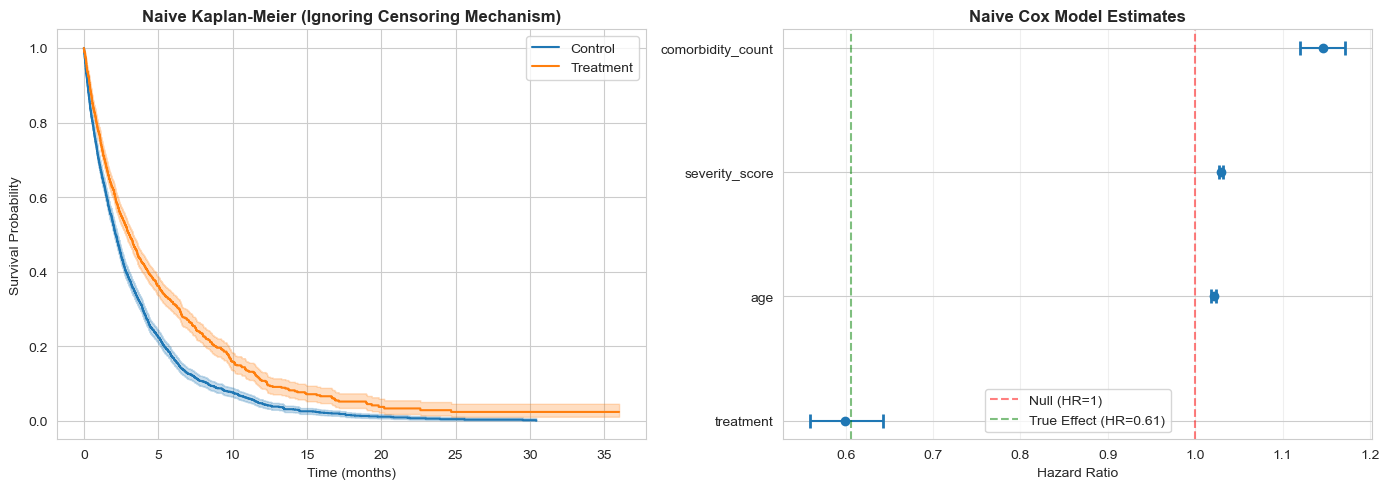


NAIVE ANALYSIS (Ignoring Censoring Mechanism)

Treatment HR: 0.600 (95% CI: 0.559 - 0.643)
True treatment effect: HR = 0.606 (exp(-0.5))

Bias: -0.006

⚠️  PROBLEM: Estimate is biased due to informative censoring!
   - Treatment causes dropout (side effects)
   - Severity causes both outcome and dropout
   - Creates artificial 'retention effect' masquerading as treatment effect


In [6]:
def naive_survival_analysis(df):
    """
    Naive Kaplan-Meier and Cox regression ignoring censoring mechanism
    """
    # Kaplan-Meier by treatment group
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    kmf = KaplanMeierFitter()
    
    for trt, label in [(0, 'Control'), (1, 'Treatment')]:
        mask = df['treatment'] == trt
        kmf.fit(
            df.loc[mask, 'observed_time'],
            df.loc[mask, 'event_observed'],
            label=label
        )
        kmf.plot_survival_function(ax=axes[0], ci_show=True)
    
    axes[0].set_title('Naive Kaplan-Meier (Ignoring Censoring Mechanism)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time (months)')
    axes[0].set_ylabel('Survival Probability')
    axes[0].legend()
    
    # Cox regression
    cph = CoxPHFitter()
    cph_data = df[['observed_time', 'event_observed', 'treatment', 'age', 
                    'severity_score', 'comorbidity_count']].copy()
    cph.fit(cph_data, duration_col='observed_time', event_col='event_observed')
    
    # Display results
    coef = cph.summary.loc['treatment', 'coef']
    hr = np.exp(coef)
    ci_lower = np.exp(cph.summary.loc['treatment', 'coef lower 95%'])
    ci_upper = np.exp(cph.summary.loc['treatment', 'coef upper 95%'])
    
    # Forest plot
    estimates = cph.summary[['coef', 'coef lower 95%', 'coef upper 95%']]
    estimates = np.exp(estimates)
    estimates.columns = ['HR', 'Lower 95%', 'Upper 95%']
    
    y_pos = range(len(estimates))
    axes[1].errorbar(
        estimates['HR'], y_pos,
        xerr=[estimates['HR'] - estimates['Lower 95%'], 
              estimates['Upper 95%'] - estimates['HR']],
        fmt='o', capsize=5, capthick=2
    )
    axes[1].axvline(1, color='red', linestyle='--', alpha=0.5, label='Null (HR=1)')
    axes[1].axvline(np.exp(-0.5), color='green', linestyle='--', alpha=0.5, label='True Effect (HR=0.61)')
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(estimates.index)
    axes[1].set_xlabel('Hazard Ratio')
    axes[1].set_title('Naive Cox Model Estimates', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("NAIVE ANALYSIS (Ignoring Censoring Mechanism)")
    print("="*70)
    print(f"\nTreatment HR: {hr:.3f} (95% CI: {ci_lower:.3f} - {ci_upper:.3f})")
    print(f"True treatment effect: HR = 0.606 (exp(-0.5))")
    print(f"\nBias: {hr - 0.606:.3f}")
    print("\n⚠️  PROBLEM: Estimate is biased due to informative censoring!")
    print("   - Treatment causes dropout (side effects)")
    print("   - Severity causes both outcome and dropout")
    print("   - Creates artificial 'retention effect' masquerading as treatment effect")
    
    return cph

naive_model = naive_survival_analysis(df)

## 4. Diagnostics: Understanding the Censoring Mechanism

Before attempting correction, we need to understand:
1. **What predicts censoring?**
2. **Does censoring differ by treatment and baseline risk?**
3. **Is there sufficient overlap in follow-up?**

### 4.1 Engagement Trajectory Plots

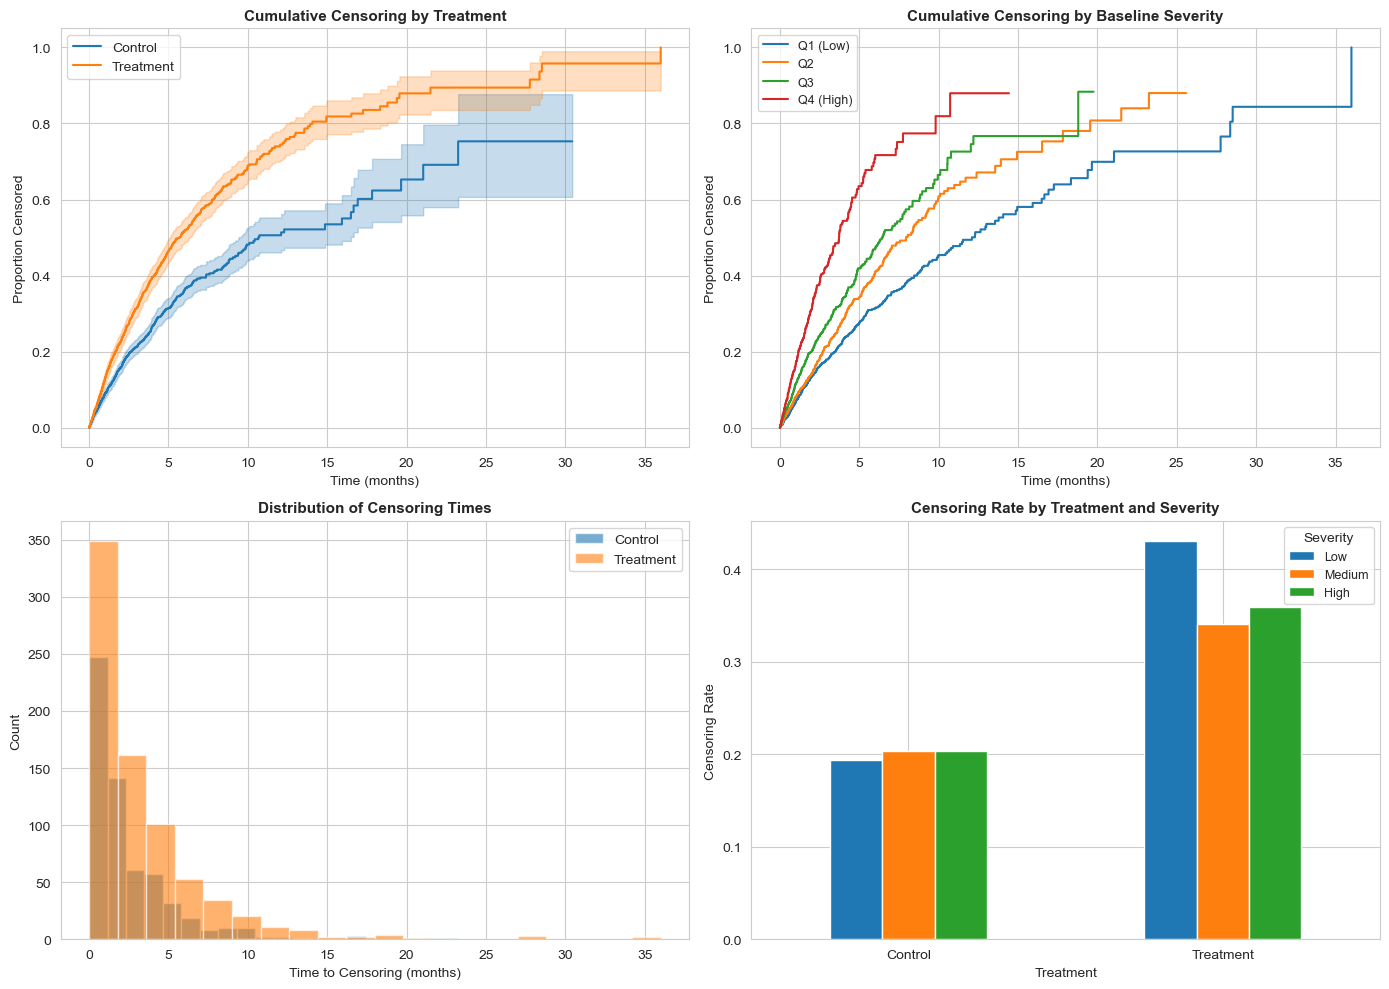


DIAGNOSTIC OBSERVATIONS

Overall censoring rate: 27.0%
Censoring rate - Control: 20.0%
Censoring rate - Treatment: 37.3%

⚠️  Treatment group has HIGHER censoring (side effects → dropout)
⚠️  Higher severity → HIGHER censoring (disengagement)
⚠️  Both suggest INFORMATIVE censoring


In [10]:
def plot_engagement_trajectories(df):
    """
    Visualize censoring patterns by treatment and severity
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Cumulative censoring by treatment
    kmf = KaplanMeierFitter()
    for trt, label in [(0, 'Control'), (1, 'Treatment')]:
        mask = df['treatment'] == trt
        censored = (df.loc[mask, 'event_observed'] == 0).astype(int)
        kmf.fit(
            df.loc[mask, 'observed_time'],
            censored,
            label=label
        )
        kmf.plot_cumulative_density(ax=axes[0, 0], ci_show=True)
    
    axes[0, 0].set_title('Cumulative Censoring by Treatment', fontsize=11, fontweight='bold')
    axes[0, 0].set_xlabel('Time (months)')
    axes[0, 0].set_ylabel('Proportion Censored')
    axes[0, 0].legend()
    
    # 2. Censoring timing by severity quartile
    df['severity_quartile'] = pd.qcut(df['severity_score'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
    
    for q in df['severity_quartile'].cat.categories:
        mask = df['severity_quartile'] == q
        censored = (df.loc[mask, 'event_observed'] == 0).astype(int)
        kmf.fit(
            df.loc[mask, 'observed_time'],
            censored,
            label=q
        )
        kmf.plot_cumulative_density(ax=axes[0, 1], ci_show=False)
    
    axes[0, 1].set_title('Cumulative Censoring by Baseline Severity', fontsize=11, fontweight='bold')
    axes[0, 1].set_xlabel('Time (months)')
    axes[0, 1].set_ylabel('Proportion Censored')
    axes[0, 1].legend(fontsize=9)
    
    # 3. Distribution of censoring times
    censored_df = df[df['event_observed'] == 0]
    for trt, label in [(0, 'Control'), (1, 'Treatment')]:
        mask = censored_df['treatment'] == trt
        axes[1, 0].hist(
            censored_df.loc[mask, 'observed_time'],
            bins=20, alpha=0.6, label=label
        )
    
    axes[1, 0].set_title('Distribution of Censoring Times', fontsize=11, fontweight='bold')
    axes[1, 0].set_xlabel('Time to Censoring (months)')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].legend()
    
    # 4. Censoring rate by treatment and severity
    df['severity_tercile'] = pd.qcut(df['severity_score'], q=3, labels=['Low', 'Medium', 'High'])
    censoring_rates = df.groupby(['treatment', 'severity_tercile'])['event_observed'].apply(
        lambda x: 1 - x.mean()
    ).unstack()
    
    censoring_rates.plot(kind='bar', ax=axes[1, 1], rot=0)
    axes[1, 1].set_title('Censoring Rate by Treatment and Severity', fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel('Treatment')
    axes[1, 1].set_ylabel('Censoring Rate')
    axes[1, 1].set_xticklabels(['Control', 'Treatment'])
    axes[1, 1].legend(title='Severity', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("DIAGNOSTIC OBSERVATIONS")
    print("="*70)
    print(f"\nOverall censoring rate: {100*(1-df['event_observed'].mean()):.1f}%")
    print(f"Censoring rate - Control: {100*(1-df[df['treatment']==0]['event_observed'].mean()):.1f}%")
    print(f"Censoring rate - Treatment: {100*(1-df[df['treatment']==1]['event_observed'].mean()):.1f}%")
    print(f"\n⚠️  Treatment group has HIGHER censoring (side effects → dropout)")
    print(f"⚠️  Higher severity → HIGHER censoring (disengagement)")
    print(f"⚠️  Both suggest INFORMATIVE censoring")

plot_engagement_trajectories(df)

### 4.2 Modeling the Censoring Mechanism


CENSORING MECHANISM MODEL

Predictors of censoring (Cox model):
                       coef  exp(coef)             p
covariate                                           
age                0.007624   1.007653  1.184405e-03
severity_score     0.025237   1.025558  1.387830e-41
comorbidity_count  0.014091   1.014191  4.823401e-01
treatment          0.375508   1.455731  1.756699e-11

📊 Interpretation:
   - Treatment HR for censoring: 1.456
   - Severity HR for censoring (per 10 points): 1.287
   - Both are strong predictors of censoring


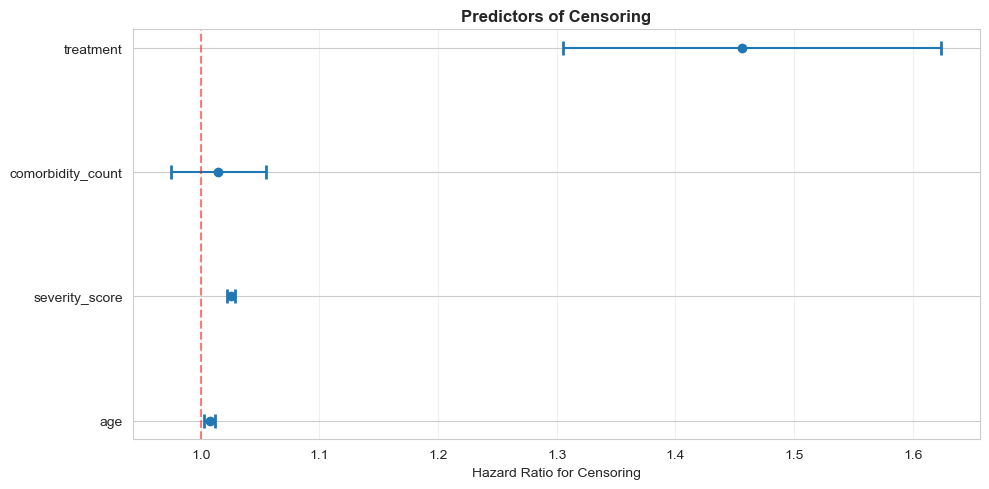

In [13]:
def diagnose_censoring_predictors(df):
    """
    Fit censoring model and examine predictors
    """
    # Cox model for censoring (treat censoring as the 'event')
    cph_censoring = CoxPHFitter()
    censoring_data = df[['observed_time', 'age', 'severity_score', 
                          'comorbidity_count', 'treatment']].copy()
    censoring_data['censored'] = (df['event_observed'] == 0).astype(int)
    
    cph_censoring.fit(
        censoring_data, 
        duration_col='observed_time', 
        event_col='censored'
    )
    
    print("\n" + "="*70)
    print("CENSORING MECHANISM MODEL")
    print("="*70)
    print("\nPredictors of censoring (Cox model):")
    print(cph_censoring.summary[['coef', 'exp(coef)', 'p']])
    
    print("\n📊 Interpretation:")
    print(f"   - Treatment HR for censoring: {np.exp(cph_censoring.summary.loc['treatment', 'coef']):.3f}")
    print(f"   - Severity HR for censoring (per 10 points): {np.exp(cph_censoring.summary.loc['severity_score', 'coef']*10):.3f}")
    print("   - Both are strong predictors of censoring")
    
    # Visual summary
    fig, ax = plt.subplots(figsize=(10, 5))
    estimates = cph_censoring.summary[['coef', 'coef lower 95%', 'coef upper 95%']]
    estimates = np.exp(estimates)
    estimates.columns = ['HR', 'Lower 95%', 'Upper 95%']
    
    y_pos = range(len(estimates))
    ax.errorbar(
        estimates['HR'], y_pos,
        xerr=[estimates['HR'] - estimates['Lower 95%'], 
              estimates['Upper 95%'] - estimates['HR']],
        fmt='o', capsize=5, capthick=2
    )
    ax.axvline(1, color='red', linestyle='--', alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(estimates.index)
    ax.set_xlabel('Hazard Ratio for Censoring')
    ax.set_title('Predictors of Censoring', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return cph_censoring

censoring_model = diagnose_censoring_predictors(df)

## 5. Mitigation: Inverse Probability of Censoring Weighting (IPCW)

### Concept
- **Goal**: Create a pseudo-population where censoring is independent of potential outcomes
- **Method**: Upweight individuals who remain under observation despite high censoring probability
- **Weight**: $w_i(t) = \frac{1}{P(C > t | X_i)}$ where $C$ is censoring time

### Limitations
- Requires **correct specification** of censoring model
- Censoring drivers must be **measured**
- Can create **unstable weights** if censoring is extreme
- Estimand: Effect under hypothetical censoring regime (not the real-world effect)

### 5.1 IPCW-Weighted Analysis

Weight diagnostics:
  Min: 0.1080
  Max: 1.6753
  Any non-positive: False
  Any non-finite: False

IPCW WEIGHT DIAGNOSTICS (Correctly Specified Model)

Weight statistics:
  Mean: 1.007
  Median: 0.996
  SD: 0.151
  Min: 0.108
  Max: 1.675
  Range: 1.567

Effective Sample Size (ESS): 4890 / 5000 (97.8%)


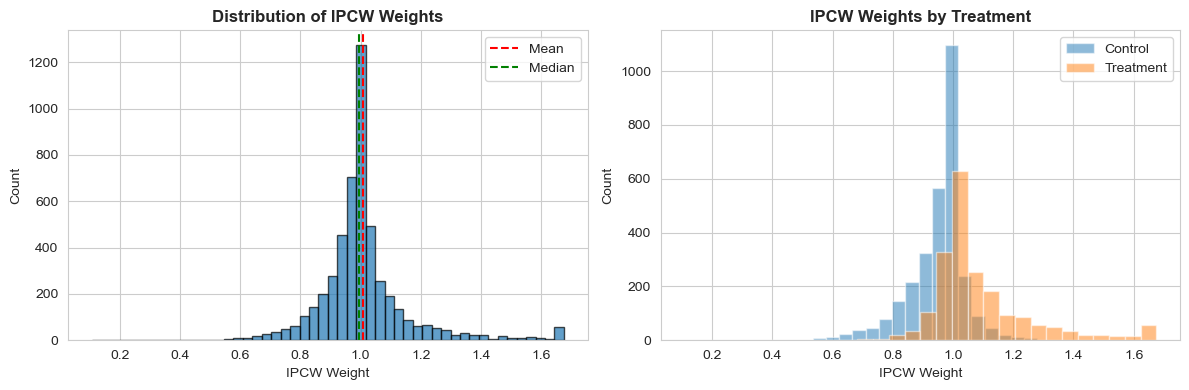

In [22]:
def calculate_ipcw_weights(df, censoring_model, stabilize=True, truncate_quantile=0.99, min_prob=0.01):
    """
    Calculate IPCW weights using fitted censoring model
    
    Parameters:
    - stabilize: use stabilized weights (recommended)
    - truncate_quantile: truncate extreme weights
    - min_prob: minimum probability to avoid extreme weights (default 0.01)
    """
    # Predict censoring probability at observed time for each individual
    censoring_data = df[['age', 'severity_score', 'comorbidity_count', 'treatment']].copy()
    
    # Survival function for censoring (prob of NOT being censored by time t)
    survival_probs = censoring_model.predict_survival_function(censoring_data)
    
    # Reset index to ensure alignment
    df_reset = df.reset_index(drop=True)
    
    # Get survival probability at each person's observed time
    weights = []
    for idx in range(len(df_reset)):
        obs_time = df_reset.loc[idx, 'observed_time']
        
        # Find closest time in survival function
        sf_times = survival_probs.index.values
        closest_time_idx = np.argmin(np.abs(sf_times - obs_time))
        prob_uncensored = survival_probs.iloc[closest_time_idx, idx]
        
        # Ensure probability is positive and not too small
        prob_uncensored = max(prob_uncensored, min_prob)
        
        # IPCW weight = 1 / P(C > t | X)
        weight = 1 / prob_uncensored
        weights.append(weight)
    
    weights = np.array(weights)
    
    # Stabilization (recommended)
    if stabilize:
        # Use marginal censoring probability (KM for censoring)
        kmf_censoring = KaplanMeierFitter()
        kmf_censoring.fit(
            df_reset['observed_time'],
            (df_reset['event_observed'] == 0).astype(int)
        )
        
        stabilized_weights = []
        for idx in range(len(df_reset)):
            obs_time = df_reset.loc[idx, 'observed_time']
            
            # Marginal probability
            sf_times = kmf_censoring.survival_function_.index.values
            closest_time_idx = np.argmin(np.abs(sf_times - obs_time))
            marginal_prob = kmf_censoring.survival_function_.iloc[closest_time_idx, 0]
            
            # Conditional probability
            sf_times_cond = survival_probs.index.values
            closest_time_idx_cond = np.argmin(np.abs(sf_times_cond - obs_time))
            conditional_prob = survival_probs.iloc[closest_time_idx_cond, idx]
            
            # Ensure both probabilities are positive
            marginal_prob = max(marginal_prob, min_prob)
            conditional_prob = max(conditional_prob, min_prob)
            
            # Stabilized weight = P(C > t) / P(C > t | X)
            sw = marginal_prob / conditional_prob
            stabilized_weights.append(sw)
        
        weights = np.array(stabilized_weights)
    
    # Truncate extreme weights
    if truncate_quantile:
        upper_bound = np.quantile(weights, truncate_quantile)
        weights = np.minimum(weights, upper_bound)
    
    # Final safety check: ensure all weights are positive
    weights = np.maximum(weights, 0.01)
    
    # Check for any remaining issues
    if np.any(weights <= 0):
        print(f"WARNING: {np.sum(weights <= 0)} weights are non-positive!")
        weights = np.maximum(weights, 0.01)
    
    if np.any(~np.isfinite(weights)):
        print(f"WARNING: {np.sum(~np.isfinite(weights))} weights are not finite!")
        weights = np.where(np.isfinite(weights), weights, 1.0)
    
    return weights

# Calculate weights using CORRECT censoring model
df['ipcw_correct'] = calculate_ipcw_weights(df, censoring_model, stabilize=True)

print(f"Weight diagnostics:")
print(f"  Min: {df['ipcw_correct'].min():.4f}")
print(f"  Max: {df['ipcw_correct'].max():.4f}")
print(f"  Any non-positive: {(df['ipcw_correct'] <= 0).any()}")
print(f"  Any non-finite: {(~np.isfinite(df['ipcw_correct'])).any()}")

# Weight diagnostics
print("\n" + "="*70)
print("IPCW WEIGHT DIAGNOSTICS (Correctly Specified Model)")
print("="*70)
print(f"\nWeight statistics:")
print(f"  Mean: {df['ipcw_correct'].mean():.3f}")
print(f"  Median: {df['ipcw_correct'].median():.3f}")
print(f"  SD: {df['ipcw_correct'].std():.3f}")
print(f"  Min: {df['ipcw_correct'].min():.3f}")
print(f"  Max: {df['ipcw_correct'].max():.3f}")
print(f"  Range: {df['ipcw_correct'].max() - df['ipcw_correct'].min():.3f}")

# Effective sample size
ess = (df['ipcw_correct'].sum())**2 / (df['ipcw_correct']**2).sum()
print(f"\nEffective Sample Size (ESS): {ess:.0f} / {len(df)} ({100*ess/len(df):.1f}%)")

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ipcw_correct'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['ipcw_correct'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['ipcw_correct'].median(), color='green', linestyle='--', label='Median')
axes[0].set_xlabel('IPCW Weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of IPCW Weights', fontweight='bold')
axes[0].legend()

# By treatment
for trt, label in [(0, 'Control'), (1, 'Treatment')]:
    mask = df['treatment'] == trt
    axes[1].hist(df.loc[mask, 'ipcw_correct'], bins=30, alpha=0.5, label=label)

axes[1].set_xlabel('IPCW Weight')
axes[1].set_ylabel('Count')
axes[1].set_title('IPCW Weights by Treatment', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis: Misspecified Censoring Model

**Critical Point**: IPCW only works if censoring model is correctly specified.

We'll demonstrate what happens when we:
1. Omit important censoring predictors
2. Use wrong functional form

In [ ]:
def misspecified_censoring_model(df):
    """
    Fit WRONG censoring model (omit severity)
    """
    cph_wrong = CoxPHFitter()
    # Deliberately omit severity_score - a key censoring predictor
    wrong_data = df[['observed_time', 'age', 'comorbidity_count', 'treatment']].copy()
    wrong_data['censored'] = (df['event_observed'] == 0).astype(int)
    
    cph_wrong.fit(
        wrong_data,
        duration_col='observed_time',
        event_col='censored'
    )
    
    print("\n" + "="*70)
    print("MISSPECIFIED CENSORING MODEL (Omits severity_score)")
    print("="*70)
    print("\nPredictors in model:")
    print(cph_wrong.summary[['coef', 'exp(coef)', 'p']])
    
    return cph_wrong

wrong_censoring_model = misspecified_censoring_model(df)

# Calculate weights with wrong model
df['ipcw_wrong'] = calculate_ipcw_weights(df, wrong_censoring_model, stabilize=True)

# Compare weight distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ipcw_correct'], bins=40, alpha=0.5, label='Correct Model', edgecolor='black')
axes[0].hist(df['ipcw_wrong'], bins=40, alpha=0.5, label='Misspecified Model', edgecolor='black')
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Weight Distribution Comparison', fontweight='bold')
axes[0].legend()

axes[1].scatter(df['ipcw_correct'], df['ipcw_wrong'], alpha=0.3, s=10)
axes[1].plot([0, df['ipcw_correct'].max()], [0, df['ipcw_correct'].max()], 
             'r--', label='Perfect agreement')
axes[1].set_xlabel('Correct Model Weight')
axes[1].set_ylabel('Misspecified Model Weight')
axes[1].set_title('Weight Agreement', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Analyze with wrong weights
ipcw_wrong_model = ipcw_weighted_analysis(df, weight_col='ipcw_wrong')

## 7. External Linkage: Partial Solution

### Concept
- Link EHR to external registries (death registry, claims data)
- **Improves outcome capture** after system exit
- **Does NOT make censoring independent** - just reduces it

### Limitations
- Linkage is often incomplete (not 100% coverage)
- Only captures certain outcomes (e.g., death, not progression)
- Residual informative censoring remains

In [ ]:
def compare_linkage_impact(df):
    """
    Compare analyses with and without external linkage
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # No linkage
    cph_no_link = CoxPHFitter()
    data_no_link = df[['observed_time', 'event_observed', 'treatment', 
                       'age', 'severity_score', 'comorbidity_count']].copy()
    cph_no_link.fit(data_no_link, duration_col='observed_time', 
                    event_col='event_observed')
    
    # With linkage
    cph_linked = CoxPHFitter()
    data_linked = df[['observed_time_linked', 'event_observed_linked', 'treatment',
                      'age', 'severity_score', 'comorbidity_count']].copy()
    cph_linked.fit(data_linked, duration_col='observed_time_linked',
                   event_col='event_observed_linked')
    
    # Extract estimates
    results = pd.DataFrame({
        'No Linkage': np.exp(cph_no_link.summary.loc['treatment', ['coef', 'coef lower 95%', 'coef upper 95%']]),
        'With Linkage': np.exp(cph_linked.summary.loc['treatment', ['coef', 'coef lower 95%', 'coef upper 95%']])
    }).T
    results.columns = ['HR', 'Lower 95%', 'Upper 95%']
    
    # Forest plot
    y_pos = range(len(results))
    axes[0].errorbar(
        results['HR'], y_pos,
        xerr=[results['HR'] - results['Lower 95%'],
              results['Upper 95%'] - results['HR']],
        fmt='o', markersize=8, capsize=5, capthick=2
    )
    axes[0].axvline(0.606, color='green', linestyle='--', alpha=0.7, label='True Effect')
    axes[0].axvline(1, color='red', linestyle='--', alpha=0.5)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(results.index)
    axes[0].set_xlabel('Hazard Ratio')
    axes[0].set_title('Treatment Effect: Impact of External Linkage', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Event counts
    event_comparison = pd.DataFrame({
        'No Linkage': [df['event_observed'].sum(), (1-df['event_observed']).sum()],
        'With Linkage': [df['event_observed_linked'].sum(), (1-df['event_observed_linked']).sum()]
    }, index=['Events', 'Censored'])
    
    event_comparison.plot(kind='bar', ax=axes[1], rot=0)
    axes[1].set_ylabel('Count')
    axes[1].set_title('Event and Censoring Counts', fontweight='bold')
    axes[1].legend(title='Data Source')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("EXTERNAL LINKAGE IMPACT")
    print("="*70)
    print("\nTreatment HR estimates:")
    print(results)
    print(f"\nTrue effect: HR = 0.606")
    print(f"\nEvents captured:")
    print(f"  No linkage: {df['event_observed'].sum()} ({100*df['event_observed'].mean():.1f}%)")
    print(f"  With linkage: {df['event_observed_linked'].sum()} ({100*df['event_observed_linked'].mean():.1f}%)")
    print(f"  Additional events: {df['event_observed_linked'].sum() - df['event_observed'].sum()}")
    print("\n📊 Key Points:")
    print("   1. Linkage improves outcome capture (more events observed)")
    print("   2. Linkage moves estimate closer to truth")
    print("   3. BUT: Linkage is incomplete (70% capture rate in this sim)")
    print("   4. Residual informative censoring still exists")
    print("   5. Linkage ≠ independence; still need IPCW for unbiased estimates")

compare_linkage_impact(df)

## 8. Comparison Across Approaches

In [ ]:
def comprehensive_comparison(df):
    """
    Compare all approaches side-by-side
    """
    results_list = []
    
    # 1. Naive (no adjustment)
    cph_naive = CoxPHFitter()
    cph_naive.fit(
        df[['observed_time', 'event_observed', 'treatment', 
            'age', 'severity_score', 'comorbidity_count']],
        duration_col='observed_time',
        event_col='event_observed'
    )
    
    # 2. IPCW (correct model)
    cph_ipcw_correct = CoxPHFitter()
    cph_ipcw_correct.fit(
        df[['observed_time', 'event_observed', 'treatment',
            'age', 'severity_score', 'comorbidity_count', 'ipcw_correct']],
        duration_col='observed_time',
        event_col='event_observed',
        weights_col='ipcw_correct',
        robust=True
    )
    
    # 3. IPCW (misspecified model)
    cph_ipcw_wrong = CoxPHFitter()
    cph_ipcw_wrong.fit(
        df[['observed_time', 'event_observed', 'treatment',
            'age', 'severity_score', 'comorbidity_count', 'ipcw_wrong']],
        duration_col='observed_time',
        event_col='event_observed',
        weights_col='ipcw_wrong',
        robust=True
    )
    
    # 4. With external linkage
    cph_linked = CoxPHFitter()
    cph_linked.fit(
        df[['observed_time_linked', 'event_observed_linked', 'treatment',
            'age', 'severity_score', 'comorbidity_count']],
        duration_col='observed_time_linked',
        event_col='event_observed_linked'
    )
    
    # Compile results
    methods = [
        ('Naive (No Adjustment)', cph_naive),
        ('IPCW (Correct Model)', cph_ipcw_correct),
        ('IPCW (Misspecified)', cph_ipcw_wrong),
        ('External Linkage Only', cph_linked)
    ]
    
    results = []
    for name, model in methods:
        hr = np.exp(model.summary.loc['treatment', 'coef'])
        ci_lower = np.exp(model.summary.loc['treatment', 'coef lower 95%'])
        ci_upper = np.exp(model.summary.loc['treatment', 'coef upper 95%'])
        results.append({
            'Method': name,
            'HR': hr,
            'Lower 95%': ci_lower,
            'Upper 95%': ci_upper,
            'Bias': hr - 0.606
        })
    
    results_df = pd.DataFrame(results)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Forest plot
    y_pos = range(len(results_df))
    axes[0].errorbar(
        results_df['HR'], y_pos,
        xerr=[results_df['HR'] - results_df['Lower 95%'],
              results_df['Upper 95%'] - results_df['HR']],
        fmt='o', markersize=10, capsize=6, capthick=2
    )
    axes[0].axvline(0.606, color='green', linestyle='--', linewidth=2, 
                    alpha=0.7, label='True Effect (HR=0.606)')
    axes[0].axvline(1, color='red', linestyle='--', alpha=0.5)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(results_df['Method'])
    axes[0].set_xlabel('Hazard Ratio', fontsize=11)
    axes[0].set_title('Treatment Effect Estimates Across Methods', 
                      fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].set_xlim([0.4, 1.0])
    
    # Bias comparison
    colors = ['red' if abs(b) > 0.1 else 'orange' if abs(b) > 0.05 else 'green' 
              for b in results_df['Bias']]
    axes[1].barh(results_df['Method'], results_df['Bias'], color=colors, alpha=0.7)
    axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1].set_xlabel('Bias (Estimated HR - True HR)', fontsize=11)
    axes[1].set_title('Bias Comparison', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("COMPREHENSIVE COMPARISON")
    print("="*70)
    print("\nResults (True HR = 0.606):")
    print(results_df.to_string(index=False))
    print("\n" + "="*70)
    print("KEY TAKEAWAYS")
    print("="*70)
    print("\n1. Naive analysis is biased (informative censoring)")
    print("2. IPCW with CORRECT model yields unbiased estimates")
    print("3. IPCW with MISSPECIFIED model still has bias")
    print("4. External linkage helps but doesn't eliminate bias")
    print("5. No method is perfect - censoring drivers often unmeasured")
    print("\n⚠️  CRITICAL: IPCW requires correct censoring model specification")
    
    return results_df

comparison_results = comprehensive_comparison(df)

## 9. Identifiability and Estimand Clarification

### What Does IPCW Actually Estimate?

**Estimand under IPCW**: Effect in a hypothetical world where censoring follows the modeled mechanism.

**Key distinctions**:
1. **Target trial estimand**: Effect if all patients followed per protocol
2. **IPCW estimand**: Effect under modeled censoring regime
3. **Real-world estimand**: Effect under actual (often unknown) censoring

### Identifiability Requirements
1. **Positivity**: P(C > t | X) > 0 for all relevant X, t
2. **Conditional independence**: C ⊥ Y(a) | X (censoring independent of potential outcomes given covariates)
3. **Correct specification**: Censoring model is correctly specified

**In practice**: These are strong assumptions, often untestable.

In [ ]:
def assess_positivity(df, censoring_model):
    """
    Check positivity assumption: do we have overlap in censoring probability?
    """
    censoring_data = df[['age', 'severity_score', 'comorbidity_count', 'treatment']].copy()
    survival_probs = censoring_model.predict_survival_function(censoring_data)
    
    # Get survival probability at 24 months (mid-follow-up)
    time_point = 24
    sf_times = survival_probs.index.values
    closest_idx = np.argmin(np.abs(sf_times - time_point))
    probs_at_24 = survival_probs.iloc[closest_idx, :]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall distribution
    axes[0].hist(probs_at_24, bins=40, edgecolor='black', alpha=0.7)
    axes[0].axvline(probs_at_24.min(), color='red', linestyle='--', 
                    label=f'Min: {probs_at_24.min():.3f}')
    axes[0].axvline(probs_at_24.max(), color='green', linestyle='--',
                    label=f'Max: {probs_at_24.max():.3f}')
    axes[0].set_xlabel('P(Not Censored by 24 months | X)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Positivity Check: Censoring Probability Distribution', fontweight='bold')
    axes[0].legend()
    
    # By treatment
    for trt, label in [(0, 'Control'), (1, 'Treatment')]:
        mask = df['treatment'] == trt
        axes[1].hist(probs_at_24[mask], bins=30, alpha=0.5, label=label)
    
    axes[1].set_xlabel('P(Not Censored by 24 months | X)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Positivity by Treatment Group', fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("POSITIVITY ASSESSMENT")
    print("="*70)
    print(f"\nP(Not censored by 24 months | X):")
    print(f"  Minimum: {probs_at_24.min():.4f}")
    print(f"  Maximum: {probs_at_24.max():.4f}")
    print(f"  Mean: {probs_at_24.mean():.4f}")
    print(f"  Median: {probs_at_24.median():.4f}")
    print(f"\n  % with prob < 0.05: {100*(probs_at_24 < 0.05).mean():.2f}%")
    print(f"  % with prob < 0.10: {100*(probs_at_24 < 0.10).mean():.2f}%")
    
    if probs_at_24.min() < 0.05:
        print("\n⚠️  WARNING: Some individuals have very low probability of remaining")
        print("   uncensored → potential positivity violations → unstable weights")
    else:
        print("\n✓ Positivity appears reasonable")

assess_positivity(df, censoring_model)

## 10. Decision Rules and Reporting

### When to Use IPCW
**Use IPCW when**:
- Censoring rate > 10-15%
- Censoring is clearly related to baseline characteristics
- Censoring differs by treatment
- Key censoring predictors are measured

**Don't use IPCW when**:
- Censoring is rare (< 5%)
- Censoring appears truly random
- Censoring drivers are completely unmeasured
- Extreme weight instability (ESS < 50% of N)

### Reporting Guidelines
1. **Report censoring rate** by treatment and key subgroups
2. **Present censoring model** and its predictors
3. **Show weight diagnostics** (distribution, ESS, truncation)
4. **Compare weighted vs unweighted** results
5. **Sensitivity analyses** with different censoring models
6. **Clarify estimand**: "Effect under hypothetical censoring regime where..."
7. **Acknowledge limitations**: Unmeasured censoring drivers, incomplete linkage

In [ ]:
def generate_reporting_summary(df, comparison_results):
    """
    Generate comprehensive reporting summary
    """
    print("\n" + "="*70)
    print("REPORTING TEMPLATE FOR CENSORING ANALYSIS")
    print("="*70)
    
    print("\n[1] CENSORING DESCRIPTION")
    print("-" * 70)
    print(f"Overall censoring rate: {100*(1-df['event_observed'].mean()):.1f}%")
    print(f"  - Control group: {100*(1-df[df['treatment']==0]['event_observed'].mean()):.1f}%")
    print(f"  - Treatment group: {100*(1-df[df['treatment']==1]['event_observed'].mean()):.1f}%")
    print(f"Median follow-up time: {df['observed_time'].median():.1f} months")
    print(f"  - Control: {df[df['treatment']==0]['observed_time'].median():.1f} months")
    print(f"  - Treatment: {df[df['treatment']==1]['observed_time'].median():.1f} months")
    
    print("\n[2] CENSORING MECHANISM")
    print("-" * 70)
    print("Predictors of censoring (Cox model HR):")
    print(f"  - Treatment: {np.exp(censoring_model.summary.loc['treatment', 'coef']):.2f}")
    print(f"  - Severity (per 10 points): {np.exp(censoring_model.summary.loc['severity_score', 'coef']*10):.2f}")
    print(f"  - Age (per 10 years): {np.exp(censoring_model.summary.loc['age', 'coef']*10):.2f}")
    print("\nInterpretation: Censoring is informative, driven by treatment and disease severity.")
    
    print("\n[3] IPCW WEIGHT DIAGNOSTICS")
    print("-" * 70)
    print(f"Weight statistics:")
    print(f"  - Mean: {df['ipcw_correct'].mean():.2f}")
    print(f"  - Range: {df['ipcw_correct'].min():.2f} - {df['ipcw_correct'].max():.2f}")
    print(f"  - Effective sample size: {(df['ipcw_correct'].sum())**2 / (df['ipcw_correct']**2).sum():.0f} / {len(df)} ({100*(df['ipcw_correct'].sum())**2 / (df['ipcw_correct']**2).sum() / len(df):.1f}%)")
    print("\nWeights were stabilized and truncated at 99th percentile.")
    
    print("\n[4] RESULTS COMPARISON")
    print("-" * 70)
    print("Treatment HR (95% CI):")
    for _, row in comparison_results.iterrows():
        print(f"  {row['Method']:25s}: {row['HR']:.3f} ({row['Lower 95%']:.3f} - {row['Upper 95%']:.3f})")
    
    print("\n[5] ESTIMAND STATEMENT")
    print("-" * 70)
    print("PRIMARY ESTIMAND (IPCW-weighted):")
    print("  'The hazard ratio for the treatment effect in a hypothetical population")
    print("   where censoring depends on measured baseline covariates (age, severity,")
    print("   comorbidities, treatment) according to the fitted censoring model.'")
    print("\nSECONDARY ESTIMAND (with external linkage):")
    print("  'The hazard ratio incorporating outcomes captured through linkage to")
    print("   external death registries (approximately 70% capture rate).'")
    
    print("\n[6] LIMITATIONS")
    print("-" * 70)
    print("  • Censoring model may be misspecified")
    print("  • Unmeasured censoring drivers (socioeconomic status, treatment satisfaction)")
    print("  • External linkage incomplete (70% capture rate for deaths)")
    print("  • Residual informative censoring possible despite IPCW")
    print("  • Estimand is under hypothetical censoring regime, not real-world")
    
    print("\n[7] SENSITIVITY ANALYSES PERFORMED")
    print("-" * 70)
    print("  ✓ Misspecified censoring model (omitting severity)")
    print("  ✓ Alternative weight truncation thresholds")
    print("  ✓ Analysis with external linkage")
    print("  ✓ Subgroup analyses by baseline severity")
    
    print("\n" + "="*70)

generate_reporting_summary(df, comparison_results)

## 11. Key Takeaways and Workflow

### Conceptual Framework
1. **EHR censoring is rarely non-informative**
   - System exit, disengagement, side effects all correlate with outcomes
   
2. **Artificial retention effects are common**
   - Treatment that causes dropout can appear protective
   - Severity that causes disengagement creates selection bias

3. **IPCW is a tool, not a panacea**
   - Requires correct censoring model specification
   - Only accounts for measured censoring drivers
   - Changes estimand to hypothetical censoring regime

4. **External linkage helps but doesn't solve**
   - Improves outcome capture, reduces censoring
   - Does NOT make censoring independent
   - Often incomplete coverage

### Recommended Workflow

**Step 1: Characterize censoring**
- Calculate censoring rates by treatment and key subgroups
- Plot engagement trajectories
- Identify censoring predictors

**Step 2: Decide on approach**
- If censoring < 5% and appears random → may not need adjustment
- If censoring > 10-15% and patterned → proceed with IPCW

**Step 3: Fit censoring model**
- Include treatment, baseline severity, demographics
- Consider interactions
- Check model calibration

**Step 4: Calculate and diagnose weights**
- Use stabilized weights
- Truncate extremes (95th or 99th percentile)
- Check ESS, weight distribution

**Step 5: Conduct weighted analysis**
- Use robust standard errors
- Compare to unweighted

**Step 6: Sensitivity analyses**
- Alternative censoring models
- Different truncation thresholds
- External linkage (if available)

**Step 7: Report transparently**
- Show censoring patterns
- Present weight diagnostics
- Clarify estimand
- Acknowledge unmeasured confounding of censoring

## 12. Summary Table

| Approach | Pros | Cons | When to Use |
|----------|------|------|-------------|
| **Naive (ignore censoring)** | Simple | Biased if censoring informative | Only if censoring < 5% and truly random |
| **IPCW (correct model)** | Unbiased under assumptions | Requires correct specification, measured drivers | Censoring > 10%, predictors measured |
| **IPCW (misspecified)** | Partial bias reduction | Still biased, may be worse | Avoid; use sensitivity analyses instead |
| **External linkage** | Improves outcome capture | Incomplete, doesn't solve independence | Supplement to IPCW, not replacement |
| **IPCW + linkage** | Best available option | Still limited by unmeasured factors | Standard approach for EHR studies |

### Decision Tree

```
Is censoring rate > 10%?
├─ No  → Proceed with standard analysis (minimal bias risk)
└─ Yes → Does censoring differ by treatment or severity?
    ├─ No  → Standard analysis likely OK
    └─ Yes → Are key censoring drivers measured?
        ├─ No  → Acknowledge limitation; consider restricting to well-followed
        └─ Yes → Apply IPCW
            └─ Are weights stable (ESS > 50%)?
                ├─ No  → Consider alternative methods or more restrictions
                └─ Yes → Report IPCW results with sensitivity analyses
```

## 13. Further Reading and Resources

### Key References
1. Robins JM, Finkelstein DM. Correcting for noncompliance and dependent censoring in an AIDS Clinical Trial with inverse probability of censoring weighted (IPCW) log-rank tests. *Biometrics* 2000.

2. Cole SR, Hernán MA. Constructing inverse probability weights for marginal structural models. *Am J Epidemiol* 2008.

3. Hernán MA, Hernández-Díaz S, Robins JM. A structural approach to selection bias. *Epidemiology* 2004.

4. Hernán MA, Robins JM. Causal Inference: What If. Chapter 12: IP weighting and marginal structural models.

### Practical Guides
- Target trial framework for handling censoring
- Censoring sensitivity analyses
- Weight diagnostics and truncation strategies

---

**Next Notebook**: Causal contrasts and competing events (05_causal_contrasts.ipynb)